In [43]:
import numpy as np

In [44]:
def loss(w, x, y):
    M = np.dot(x, w) * y
    return np.log2(1 + np.exp(-M))

def df(w, x, y):
    M = np.dot(w, x) * y
    return -(np.exp(-M) * x.T * y) / ((1 + np.exp(-M)) * np.log(2))

data_x = [(3.0, 4.9), (2.7, 3.9), (3.0, 5.5), (2.6, 4.0), (2.9, 4.3), (3.1, 5.1), (2.2, 4.5), (2.3, 3.3), (2.7, 5.1), (3.3, 5.7), (2.8, 5.1), (2.8, 4.9), (2.5, 4.5), (2.8, 4.7), (3.2, 4.7), (3.2, 5.7), (2.8, 6.1), (3.6, 6.1), (2.8, 4.8), (2.9, 4.5), (3.1, 4.9), (2.3, 4.4), (3.3, 6.0), (2.6, 5.6), (3.0, 4.4), (2.9, 4.7), (2.8, 4.0), (2.5, 5.8), (2.4, 3.3), (2.8, 6.7), (3.0, 5.1), (2.3, 4.0), (3.1, 5.5), (2.8, 4.8), (2.7, 5.1), (2.5, 4.0), (3.1, 4.4), (3.8, 6.7), (3.1, 5.6), (3.1, 4.7), (3.0, 5.8), (3.0, 5.2), (3.0, 4.5), (2.7, 4.9), (3.0, 6.6), (2.9, 4.6), (3.0, 4.6), (2.6, 3.5), (2.7, 5.1), (2.5, 5.0), (2.0, 3.5), (3.2, 5.9), (2.5, 5.0), (3.4, 5.6), (3.4, 4.5), (3.2, 5.3), (2.2, 4.0), (2.2, 5.0), (3.3, 4.7), (2.7, 4.1), (2.4, 3.7), (3.0, 4.2), (3.2, 6.0), (3.0, 4.2), (3.0, 4.5), (2.7, 4.2), (2.5, 3.0), (2.8, 4.6), (2.9, 4.2), (3.1, 5.4), (2.5, 4.9), (3.2, 5.1), (2.8, 4.5), (2.8, 5.6), (3.4, 5.4), (2.7, 3.9), (3.0, 6.1), (3.0, 5.8), (3.0, 4.1), (2.5, 3.9), (2.4, 3.8), (2.6, 4.4), (2.9, 3.6), (3.3, 5.7), (2.9, 5.6), (3.0, 5.2), (3.0, 4.8), (2.7, 5.3), (2.8, 4.1), (2.8, 5.6), (3.2, 4.5), (3.0, 5.9), (2.9, 4.3), (2.6, 6.9), (2.8, 5.1), (2.9, 6.3), (3.2, 4.8), (3.0, 5.5), (3.0, 5.0), (3.8, 6.4)]
data_y = [1, -1, 1, -1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, -1, 1, -1, 1, 1, -1, 1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, -1, 1, 1, 1, -1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1, 1]

x_train = np.array([[1, x[0], x[1]] for x in data_x]) # (N, 3)
y_train = np.array(data_y)

n_train = len(x_train)
w = np.array([0.0, 0.0, 0.0]) # (3,) 
nt = np.array([0.5, 0.01, 0.01])
lm = 0.01
N = 1000

Qe = np.mean(loss(w, x_train, y_train))
np.random.seed(0)

In [45]:
print(f'Qe = {Qe:.4f}')

Qe = 1.0000


In [46]:
for _ in range(N):
    k = np.random.randint(0, n_train-1)
    x_k = x_train[k]
    y_k = y_train[k]
    Lk = loss(w, x_k, y_k)
    w = w - nt * df(w, x_k, y_k)
    Qe = lm*Lk + (1-lm)*Qe
Q = np.mean(loss(w, x_train, y_train))

In [47]:
print(f'w = {w}')
print(f'Qe = {Qe:.4f}')
print(f'Q = {Q:.4f}')


w = [-8.15553401 -0.15656274  1.78240069]
Qe = 0.5640
Q = 0.4974


In [48]:
data_y == 1

False

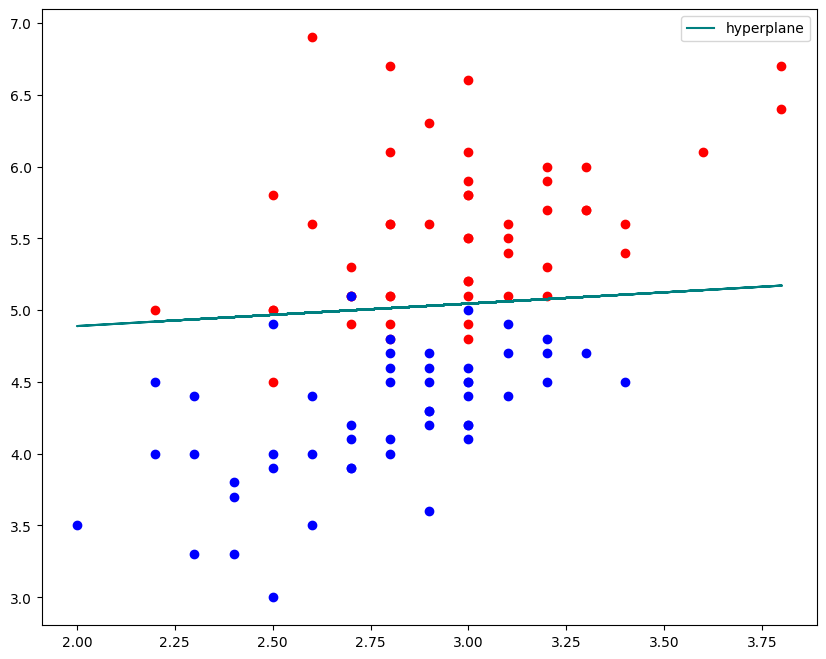

In [49]:
import matplotlib.pyplot as plt
data_x = np.array(data_x)
data_y = np.array(data_y)
x_0 = data_x[data_y == 1]
x_1 = data_x[data_y == -1]
line_x = data_x[:, 0]
line_y = -w[1]*data_x[:, 0] - w[0] / w[2]
plt.figure(figsize=(10, 8))
plt.scatter(x_0[:, 0], x_0[:, 1], c='red')
plt.scatter(x_1[:, 0], x_1[:, 1], c='blue')
plt.plot(line_x, line_y, c='teal', label = 'hyperplane')
plt.legend()
plt.show()